# Model Audit — Data Window, Baseline, and Identifiability

The first notebook fits a baseline MMM. This notebook audits it: it treats every judgment call in that fit as something to check, and asks which conclusions the data actually supports.

**What the audit found**

1. **Two data issues were mishandled.** Zero-sales days are a monthly reporting gap, not an incomplete tail, and the real problem is a structural break in March 2024 that the original cleaning missed. It sat inside the test set.
2. **Channel priors depend on library version.** Notebook 1 builds spend-share priors in alphabetical order. The current PyMC-Marketing release keeps channels in column order, so re-running notebook 1 today would silently give each channel another channel's prior.
3. **The original specification has a degenerate baseline.** With the data fixed, it attributes more than 100% of sales to media and gives a negative baseline. Its out-of-sample error is still the best of the specifications tested, so out-of-sample error alone cannot catch this.
4. **Most channel effects are prior-driven.** For most channels the posterior is barely narrower than the prior, and carryover is not identified for 9 of 12 channels.
5. **ROAS is reported with 94% credible intervals**, and prior-driven channels are labeled as such instead of being given a point estimate.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append("src")

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pymc_extras.prior import Prior
from pymc_marketing.metrics import crps
from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.multidimensional import MMM

from data_prep import BREAK_DATE, channel_columns, impute_reporting_gaps, load_daily, to_weekly

DATA_PATH = "stunnerz_skateboards_simulated_data.csv"
SEED = sum(map(ord, "stunnerz_mmm"))
plt.rcParams["figure.dpi"] = 110

## 1. Data issues

### 1a. Zero-sales days are a monthly reporting gap

The first notebook read the zero-sales rows as an incomplete tail and dropped them. They are not at the tail: every one falls on the **first Tuesday of a month**, from 2021 through March 2024, and media spend on those days is normal. Dropping them left 38 weeks with six days of sales, which creates an artificial ~14% dip every month for the model to explain.

Fix: impute each gap from the same weekday one week before and after, and keep a flag.

In [2]:
daily = load_daily(DATA_PATH)
channels = channel_columns(daily)
zero = daily[daily["total_sales"] <= 0]

print(f"Zero-sales days: {len(zero)}")
print("Weekdays:", zero["weekday"].unique().tolist())
print("All in the first 7 days of the month:", bool((zero["date"].dt.day <= 7).all()))
print(f"Mean spend on zero-sales days: {zero[channels].sum(axis=1).mean():,.0f} vs overall {daily[channels].sum(axis=1).mean():,.0f}")

Zero-sales days: 39
Weekdays: ['Tuesday']
All in the first 7 days of the month: True
Mean spend on zero-sales days: 7,596 vs overall 8,198


### 1b. The real problem: a structural break in March 2024

From **17 March 2024**, daily sales drop by about 85% and keep decaying toward zero while spend continues at normal levels. Sales values also switch from full precision to two decimal places on that date, which points to a change in the upstream data feed rather than a real collapse in demand.

None of these days are exactly zero, so the original cleaning kept them, and they made up most of the original test set. That is why the original out-of-sample error looked so poor.

Fix: end the modeling window before the break, and keep only complete weeks.

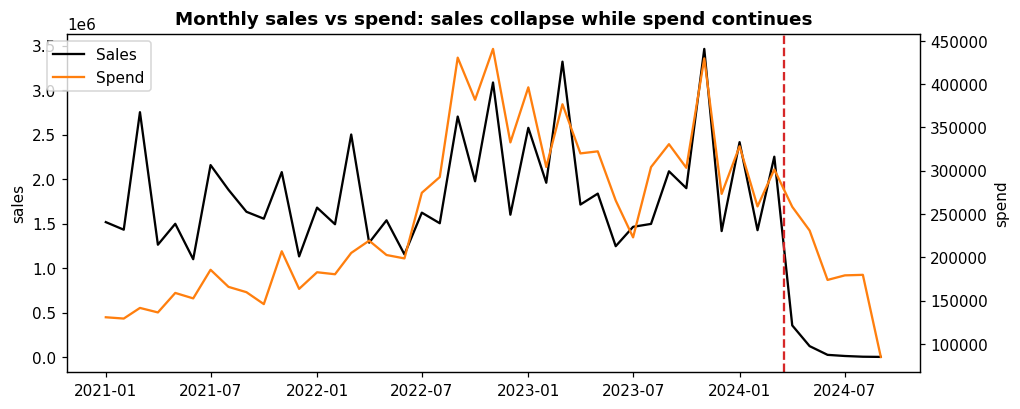

after
before break    10.0
after break      2.0
Name: decimals, dtype: float64


In [3]:
monthly = daily.set_index("date")[[*channels, "total_sales"]].resample("MS").sum()
monthly["spend"] = monthly[channels].sum(axis=1)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(monthly.index, monthly["total_sales"], color="black", label="Sales")
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["spend"], color="C1", label="Spend")
ax1.axvline(pd.Timestamp(BREAK_DATE), color="C3", linestyle="--")
ax1.set_title("Monthly sales vs spend: sales collapse while spend continues", fontweight="bold")
ax1.set_ylabel("sales"); ax2.set_ylabel("spend")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.88))
plt.show()

def decimals(x):
    s = f"{x:.10f}".rstrip("0")
    return len(s.split(".")[1]) if "." in s else 0

prec = daily.assign(decimals=daily["total_sales"].map(decimals), after=daily["date"] >= BREAK_DATE)
print(prec[prec["total_sales"] > 0].groupby("after")["decimals"].median().rename({False: "before break", True: "after break"}))

### 1c. Channel priors must be aligned by name, not by position

Notebook 1 computes spend shares with a `groupby("channel")`, which sorts channels alphabetically, then passes them as a plain array. The model assigns that array by position to its channel order. Older PyMC-Marketing releases sorted channels alphabetically, so the two lined up. The current release keeps the CSV column order, so the same code now silently assigns each channel the wrong prior:

In [4]:
alphabetical = sorted(channels)
share = daily[channels].sum() / daily[channels].sum().sum()
misaligned = pd.DataFrame({
    "correct prior sigma (own spend share)": share[channels].values,
    "sigma assigned by position": share[alphabetical].values,
}, index=pd.Index(channels, name="model channel order"))
misaligned.round(3)

,correct prior sigma (own spend share),sigma assigned by position
model channel order,,
google_display,0.005,0.011
google_search_brand,0.076,0.015
google_search_nob,0.092,0.230
facebook_pr,0.230,0.149
facebook_rt,0.149,0.028
google_discovery,0.028,0.005
bing_search_brand,0.011,0.350
bing_shopping_feed,0.015,0.076
pinterest_viz,0.018,0.092


Google brand search, for example, would get a prior scale about five times smaller than its spend share implies. Nothing errors, so this can only be caught by checking alignment explicitly. Below, priors are always built from `X[channels]` in the model's own channel order, and `requirements.txt` pins the library version.

In [5]:
weekly, channels, controls = to_weekly(impute_reporting_gaps(daily))
split = int(len(weekly) * 0.8)
train, test = weekly.iloc[:split], weekly.iloc[split:]
X_train, y_train = train.drop(columns="sales"), train["sales"]
X_test, y_test = test.drop(columns="sales"), test["sales"]

print(f"Modeling window: {weekly['date'].min().date()} to {weekly['date'].max().date()} ({len(weekly)} complete weeks)")
print(f"Train: {len(train)} weeks, test: {len(test)} weeks (test starts {test['date'].min().date()})")

Modeling window: 2021-01-05 to 2024-03-05 (166 complete weeks)
Train: 132 weeks, test: 34 weeks (test starts 2023-07-18)


## 2. Baseline audit

Each specification is fit at full sampling (4 chains, 1,500 tuning and 1,000 draws). The earlier fit used 500 draws, and sampling problems such as divergences do not reliably show up at reduced sampling.

| Spec | Change from the original |
|---|---|
| A. Original priors | Same priors as notebook 1, on the corrected data |
| B. Positive baseline | Intercept constrained to be non-negative (HalfNormal) |
| C. Brand search as control | Positive baseline, and brand search moved from media to controls, since brand search spend tends to follow demand rather than create it |

In [6]:
def spend_share_sigma(X, chans):
    share = X[chans].sum() / X[chans].sum().sum()
    return np.clip(share.values, 0.01, None)


def fit_spec(name, intercept_prior, brand_as_control=False):
    Xtr, Xte, chans, ctrls = X_train.copy(), X_test.copy(), list(channels), list(controls)
    if brand_as_control:
        brand = ["google_search_brand", "bing_search_brand"]
        chans = [c for c in chans if c not in brand]
        for b in brand:
            scale = Xtr[b].max()
            Xtr[b], Xte[b] = Xtr[b] / scale, Xte[b] / scale
        ctrls += brand

    config = {
        "intercept": intercept_prior,
        "saturation_beta": Prior("HalfNormal", sigma=spend_share_sigma(Xtr, chans), dims="channel"),
        "gamma_control": Prior("Normal", mu=0, sigma=1, dims="control"),
        "gamma_fourier": Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
        "likelihood": Prior("TruncatedNormal", lower=0, sigma=Prior("HalfNormal", sigma=1)),
    }
    mmm = MMM(
        model_config=config, target_column="sales", date_column="date",
        channel_columns=chans, control_columns=ctrls,
        adstock=GeometricAdstock(l_max=8), saturation=LogisticSaturation(), yearly_seasonality=3,
    )
    mmm.build_model(Xtr, y_train)
    mmm.add_original_scale_contribution_variable(var=["channel_contribution", "intercept_contribution", "y"])
    mmm.sample_prior_predictive(Xtr, y_train, samples=1_000)
    mmm.fit(X=Xtr, y=y_train, target_accept=0.95, chains=4, draws=1_000, tune=1_500,
            random_seed=SEED, progressbar=False)
    mmm.sample_posterior_predictive(X=Xtr, random_seed=SEED, progressbar=False)
    pred = mmm.sample_posterior_predictive(Xte, include_last_observations=True, random_seed=SEED,
                                           extend_idata=False, progressbar=False)
    pred = pred["y_original_scale"].unstack().transpose(..., "date")
    return {"name": name, "mmm": mmm, "X_train": Xtr, "channels": chans, "test_pred": pred}


def summarize(res):
    post = res["mmm"].idata.posterior
    total = y_train.sum()
    base = post["intercept_contribution_original_scale"]
    base = base.sum("date") if "date" in base.dims else base * len(y_train)
    base = (base / total).values.ravel()
    media = (post["channel_contribution_original_scale"].sum(("date", "channel")) / total).values.ravel()
    diag = az.summary(res["mmm"].idata, var_names=["intercept_contribution", "saturation_beta",
                                                   "saturation_lam", "adstock_alpha", "gamma_control"])
    pred = res["test_pred"]
    samples = pred.stack(sample=("chain", "draw")).values.T
    mape = np.mean(np.abs(pred.mean(dim=("chain", "draw")).values - y_test.values) / y_test.values)
    return {
        "spec": res["name"],
        "divergences": int(res["mmm"].idata.sample_stats["diverging"].sum()),
        "max R-hat": diag["r_hat"].max(),
        "min ESS": int(diag["ess_bulk"].min()),
        "baseline share": f"{base.mean():.0%} [{np.percentile(base, 3):.0%}, {np.percentile(base, 97):.0%}]",
        "media share": f"{media.mean():.0%} [{np.percentile(media, 3):.0%}, {np.percentile(media, 97):.0%}]",
        "test CRPS": round(crps(y_test.to_numpy(), samples)),
        "test MAPE": f"{mape:.1%}",
    }

In [7]:
specs = {
    "A. Original priors": fit_spec("A. Original priors", Prior("Normal", mu=0.2, sigma=0.1)),
    "B. Positive baseline": fit_spec("B. Positive baseline", Prior("HalfNormal", sigma=0.3)),
    "C. Brand search as control": fit_spec("C. Brand search as control", Prior("HalfNormal", sigma=0.3),
                                           brand_as_control=True),
}
audit = pd.DataFrame([summarize(r) for r in specs.values()]).set_index("spec")
audit

Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y, y_sigma]


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 258 seconds.


...

NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 224 seconds.


Sampling: [y]


Sampling: [y]


,divergences,max R-hat,min ESS,baseline share,media share,test CRPS,test MAPE
spec,,,,,,,
A. Original priors,1,1.0,2517,"-28% [-61%, 4%]","106% [75%, 140%]",72506,21.7%
B. Positive baseline,0,1.0,1786,"5% [0%, 18%]","77% [60%, 94%]",80323,26.0%
C. Brand search as control,0,1.0,2511,"3% [0%, 12%]","41% [22%, 64%]",93739,36.9%


### What the baseline audit shows

- **Spec A is not a valid model.** Media explains more than 100% of sales and the baseline is negative, which is impossible. It still has the **lowest test error**. A model selected on out-of-sample error alone would ship this.
- **Specs B and C remove the impossibility**, but the baseline sits near its lower bound (roughly 3–5% of sales). For a consumer brand that is implausibly low. The data cannot separate organic demand from media here, so the constraint and the prior are making the decision, not the data.
- **Fixing the data moved test error more than any specification change.** Test CRPS fell from about 111K in notebook 1 to about 72K with the same priors. Most of the original out-of-sample error came from the structural break sitting inside the test set, not from the model.

**Decision:** use **Spec B** for interpretation. It has no impossible values, samples cleanly, and keeps brand search in the media set so its effect stays visible. Its baseline is reported as prior-constrained, and the correct fix is external calibration (a geo holdout or brand search pause test), not a different prior chosen to hit a target number.

## 3. Which effects are data-driven?

For each channel parameter, compare the posterior spread to the prior spread. If the posterior is almost as wide as the prior, the data added little and the estimate is **prior-driven**.

`sd ratio = posterior sd / prior sd` — below 0.5 means the data clearly informed the estimate; above 0.8 means it mostly did not. A ratio above 1 means the posterior is *wider* than the prior: the data is pulling against the prior (prior-data conflict), which is its own warning sign.

In [8]:
best = specs["B. Positive baseline"]
idata = best["mmm"].idata

rows = []
for ch in best["channels"]:
    row = {"channel": ch}
    for var in ["saturation_beta", "saturation_lam", "adstock_alpha"]:
        prior_sd = float(idata.prior[var].sel(channel=ch).std())
        post_sd = float(idata.posterior[var].sel(channel=ch).std())
        row[var] = post_sd / prior_sd
    rows.append(row)

ident = pd.DataFrame(rows).set_index("channel")
worst = ident[["saturation_beta", "saturation_lam"]].max(axis=1)
ident["status"] = np.select(
    [ident["saturation_beta"] > 1.0, worst > 0.8, worst > 0.5],
    ["prior-data conflict", "prior-driven", "weakly identified"],
    default="data-driven",
)
ident.round(2).sort_values("saturation_beta")

,saturation_beta,saturation_lam,adstock_alpha,status
channel,,,,
facebook_pr,0.52,0.80,0.93,prior-driven
facebook_rt,0.53,0.76,0.92,weakly identified
google_pmax,0.65,0.57,0.76,weakly identified
bing_shopping_feed,0.82,1.05,0.98,prior-driven
pinterest_pr,0.85,0.90,0.97,prior-driven
pinterest_viz,0.87,0.90,0.97,prior-driven
pinterest_rt,0.91,0.91,0.98,prior-driven
google_search_nob,0.95,0.68,0.44,prior-driven
bing_search_brand,0.96,0.99,0.94,prior-driven


In [9]:
carryover_prior_driven = (ident["adstock_alpha"] > 0.8).sum()
print(f"Carryover (adstock) is prior-driven for {carryover_prior_driven} of {len(ident)} channels.")

Carryover (adstock) is prior-driven for 9 of 12 channels.


### Brand search: report the combined effect

Google and Bing brand search spend move together (r = 0.815), so the data has little information about how to split credit between them. Notebook 1 reported Google brand search as the top channel with a point-estimate ROAS of 31.7. With the corrected data, that value sits at the very top of a wide interval. The combined brand search effect is the more defensible quantity to report.

In [10]:
post = idata.posterior["channel_contribution_original_scale"].sum("date")
brand = ["google_search_brand", "bing_search_brand"]
spend = best["X_train"][brand].sum()

for ch in brand:
    r = (post.sel(channel=ch) / spend[ch]).values.ravel()
    print(f"{ch:22s} ROAS {r.mean():7.1f}  94% interval [{np.percentile(r, 3):.1f}, {np.percentile(r, 97):.1f}]")

combined = (post.sel(channel=brand).sum("channel") / spend.sum()).values.ravel()
print(f"{'brand search combined':22s} ROAS {combined.mean():7.1f}  94% interval [{np.percentile(combined, 3):.1f}, {np.percentile(combined, 97):.1f}]")
print("\nNotebook 1 point estimates: google_search_brand 31.7, bing_search_brand 14.4")

google_search_brand    ROAS    17.3  94% interval [2.3, 34.9]
bing_search_brand      ROAS    12.8  94% interval [0.5, 38.9]
brand search combined  ROAS    16.7  94% interval [3.5, 31.9]

Notebook 1 point estimates: google_search_brand 31.7, bing_search_brand 14.4


## 4. ROAS with uncertainty

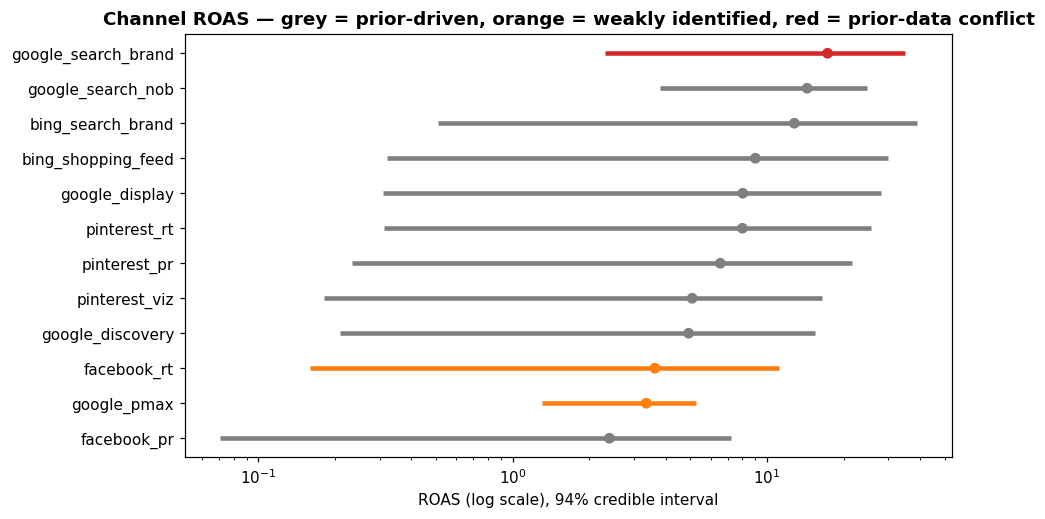

,ROAS mean,3%,97%,status
channel,,,,
google_search_brand,17.30,2.31,34.90,prior-data conflict
google_search_nob,14.37,3.81,24.78,prior-driven
bing_search_brand,12.80,0.51,38.94,prior-driven
bing_shopping_feed,9.00,0.32,29.93,prior-driven
google_display,8.03,0.31,27.96,prior-driven
pinterest_rt,8.00,0.31,25.54,prior-driven
pinterest_pr,6.56,0.23,21.49,prior-driven
pinterest_viz,5.08,0.18,16.49,prior-driven
google_discovery,4.92,0.21,15.44,prior-driven


In [11]:
spend = best["X_train"][best["channels"]].sum()
records = []
for ch in best["channels"]:
    r = (post.sel(channel=ch) / spend[ch]).values.ravel()
    records.append({"channel": ch, "ROAS mean": r.mean(), "3%": np.percentile(r, 3), "97%": np.percentile(r, 97)})
roas = pd.DataFrame(records).set_index("channel").join(ident["status"]).sort_values("ROAS mean")

fig, ax = plt.subplots(figsize=(9, 5))
colors = roas["status"].map({"data-driven": "C0", "weakly identified": "C1", "prior-driven": "C7", "prior-data conflict": "C3"})
ax.hlines(roas.index, roas["3%"], roas["97%"], color=colors, linewidth=3)
ax.scatter(roas["ROAS mean"], roas.index, color=colors, zorder=3)
ax.set_xscale("log")
ax.set_xlabel("ROAS (log scale), 94% credible interval")
ax.set_title("Channel ROAS — grey = prior-driven, orange = weakly identified, red = prior-data conflict", fontweight="bold")
plt.show()

roas.round(2).sort_values("ROAS mean", ascending=False)

## 5. Conclusions

- **Data first.** The biggest improvement came from fixing the monthly reporting gap and ending the window before the March 2024 break, not from changing the model.
- **Out-of-sample error is not enough.** The best-scoring specification was the impossible one. A model acceptance gate needs explicit baseline and media-share checks alongside error metrics.
- **Report uncertainty, not rankings.** Most channel ROAS intervals are wide and overlap. Channels where the posterior barely moved from the prior should be shown as prior-driven, not ranked.
- **Priors must be checked, not assumed.** A version change silently misassigned every channel prior in notebook 1.
- **Brand search needs an experiment.** The Google/Bing split is poorly identified, and the baseline depends on how brand search is treated. A brand search holdout or geo test is the most valuable next measurement.

**Next:** turn these checks into an automated acceptance gate (`src/acceptance_gate.py`) that grades a fitted model without manual review.